# Do big advertisers make better stocks? 📺
### "Brand capital" — the intangible the market supposedly under-prices — and why the tape says the opposite

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

Here's a genuinely appealing idea. When Coca-Cola or Procter & Gamble spends billions on advertising, that money doesn't vanish — it buys something durable: brand awareness, loyalty, pricing power. Accountants can't put "the Coca-Cola brand" on the balance sheet, so (the theory goes) the market *under-values* it — and firms that advertise heavily should therefore earn a quiet **return premium** as that hidden asset gets recognised.

It's a real academic thesis (Belo-Lin-Vitorino; Chan-Lakonishok-Sougiannis). So we sorted a basket of brand-name companies by how much of their sales they plough into advertising, and bought the heavy spenders. The result is a clean, honest **no**.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** SEC-filed advertising ÷ sales, 46 consumer names that actually disclose the line, monthly total returns 2010→2026. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from advertising_brand import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    REAL = data.load_real(allow_survivorship_bias=True)   # survivorship named on the Signal axis
    SIG = data.build_signal(REAL)
else:
    REAL = SIG = None
print("real cache present:", HAVE_REAL,
      "| basket names:", (0 if REAL is None else REAL["returns"].shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2010-02-28', 'end': '2026-06-30', 'n_months': 196, 'n_basket': 46, 'n_adv_names': 46, 'adv_fill_pct': 88, 'adv_fy_min': 2008, 'adv_fy_max': 2026, 'n_marketing': 9, 'long_cagr': 12.81, 'long_sh': 0.92, 'long_dd': -28.2, 'long_mean': 13.12, 'short_cagr': 16.17, 'short_sh': 1.11, 'short_dd': -22.3, 'short_mean': 16.13, 'ls_cagr': -3.32, 'ls_sh': -0.35, 'ls_dd': -45.9, 'spy_cagr': 14.56, 'spy_sh': 1.02, 'spy_dd': -23.9, 'spy_mean': 14.71, 'ls_mean': -3.0, 'ls_t': -1.46, 'ls_net_mean': -4.0, 'ls_net_t': -1.94, 'long_spy_mean': -1.47, 'long_spy_t': -0.62, 'short_spy_mean': 1.54, 'short_spy_t': 0.65, 'welch_legs': -0.6, 'hit': 91, 'n_ls': 196, 'hit_pct': 46.4, 'wilson_lo': 39.6, 'wilson_hi': 53.4, 'turnover_pct': 1.04, 'placebo_pctile': 13.3, 'placebo_p': 0.2, 'placebo_null_mean': -0.18, 'placebo_null_sd': 2.34, 'rob': {'half': (-0.68, -0.41), 'tertile': (-3.0, -1.46), 'quartile': (-3.47, -1.33), 'quintile': (-2.24, -0.81)}, 'syn_edge0': (0.47, 0.18), 'syn_edge6': (6.47, 2.47), 'syn_edge8': (8.47, 3.23), 'syn_null20_mean': -0.22, 'syn_null20_sd': 0.43, 'syn_null20_fire': 0, 'top_intens': [('ETSY', 27.4), ('EXPE', 26.5), ('CL', 13.3), ('CHD', 11.4), ('DPZ', 11.3), ('KO', 11.3)], 'bot_intens': [('TGT', 1.41), ('LOW', 1.1), ('TJX', 1.09), ('HD', 0.75), ('WMT', 0.75), ('ROST', 0.33)], 'long_final': ['CHD', 'CL', 'CLX', 'CMCSA', 'DECK', 'DIS', 'DPZ', 'EBAY', 'ETSY', 'EXPE', 'KO', 'NKE', 'PG', 'STZ', 'TAP'], 'short_final': ['BBY', 'CAG', 'CMG', 'F', 'HD', 'LOW', 'ROST', 'SBUX', 'SJM', 'T', 'TGT', 'TJX', 'VZ', 'WMT', 'YUM'], 'cost_bps': 10, 'borrow_bps': 100, 'fp': '979148cad57d'}


real cache present: True | basket names: 46


## The answer first

| Question | Answer |
|---|---|
| Do heavy advertisers out-earn light ones? | **No — the reverse, if anything.** Buying the heaviest advertisers and shorting the lightest *lost* about **3.0%/yr** over 2010-2026. |
| Is that loss statistically real? | **No.** It's inside the noise (*t* = -1.46, and you need \|t\| ≥ 2 to say anything). So the honest reading is: **no brand premium here at all**, in either direction. |
| So who won — the heavy or the light advertisers? | The **light** ones — big-box and off-price retailers (Walmart, Ross, TJX) that advertise almost nothing beat the brand-heavy staples (Coke, P&G, Clorox). But that's the **sector story of the decade**, not an advertising signal. |
| Could you trade it? | **No.** The spread is the wrong sign for the claim, insignificant, and a short book pays borrow on top. |

> The brand-capital *idea* is lovely. On a clean tape of firms that actually report their ad spend, it simply isn't paid — and over this window it pointed the *other* way.

## 1 · The claim

> *"Advertising builds brand capital — a durable intangible asset. GAAP expenses it immediately instead of capitalising it, so the market systematically under-values heavy advertisers. Buy them and collect the premium as the mispricing corrects."*

This is the advertising-specific version of a serious research literature on intangibles (we test its cousins elsewhere: [R&D](../../525-r-and-d-intensity/), [intangible-adjusted value](../../526-intangible-value/), [patents](../../400-patent-intensity/)). The signal is simple and mechanical: **advertising expense ÷ sales**, straight off the income statement.

## 2 · So what?

If it worked, it would be a beautifully simple factor: read one line off a 10-K, rank, buy the top. No forecasting, no models. And it would say something deep about markets — that they can't see through accounting conventions to value the brands we all obviously recognise. That's exactly the kind of clean, intuitive claim worth testing hard, precisely because it's so easy to *want* to be true.

## 3 · How would we even know?

- **The basket.** 46 long-listed US consumer companies that *actually file* an advertising line — from ad-drenched marketplaces (Etsy, Expedia ~27% of sales) and classic brand builders (Coke, P&G, Clorox ~11%) down to retailers that barely advertise (Ross 0.3%, Walmart 0.8%).
- **The sort.** Each month, rank by advertising/sales; go long the heavy-third, short the light-third; hold a month; repeat.
- **The honest scope.** *Most* public firms don't report advertising at all — so this is a slice of disclosers, not the market. We say so loudly.
- **What would make us say "mirage."** If the long-short doesn't clear *t* = 2 in the **positive** direction, there is no brand premium to trade.

## 4 · The teardown — let's actually look

**First: who advertises, and who doesn't?** The spread across the basket is huge — two orders of magnitude.

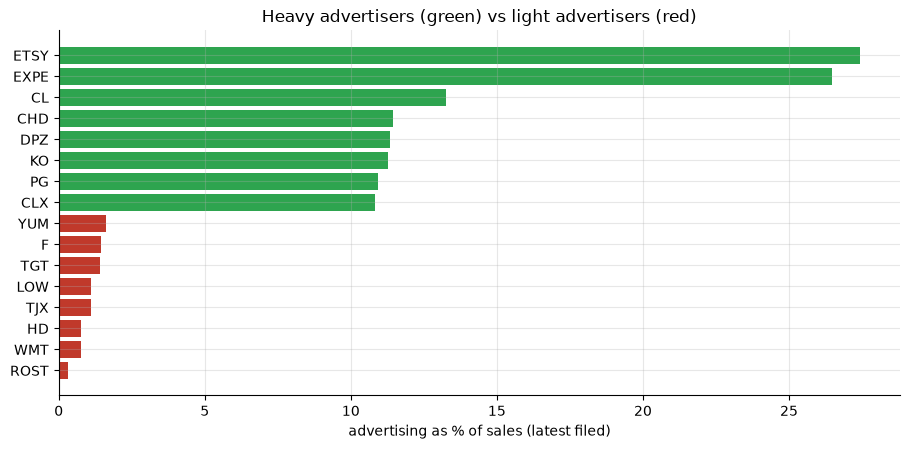

heaviest: ['ETSY 27%', 'EXPE 26%', 'CL 13%', 'CHD 11%']
lightest: ['TJX 1.1%', 'HD 0.8%', 'WMT 0.7%', 'ROST 0.3%']


In [2]:
if HAVE_REAL:
    last = SIG.dropna(how='all').index.max()
    row = SIG.loc[last].dropna().sort_values(ascending=False)
    top = row.head(8) * 100; bot = row.tail(8) * 100
else:
    top = pd.Series(dict(R['top_intens'])); bot = pd.Series(dict(R['bot_intens']))
fig, ax = plt.subplots(figsize=(9.2, 4.6))
vals = pd.concat([top, bot]);
cols = [GREEN]*len(top) + [RED]*len(bot)
ax.barh(range(len(vals)), vals.values, color=cols)
ax.set_yticks(range(len(vals))); ax.set_yticklabels(vals.index)
ax.invert_yaxis(); ax.set_xlabel('advertising as % of sales (latest filed)')
ax.set_title('Heavy advertisers (green) vs light advertisers (red)')
plt.tight_layout(); plt.show()
print('heaviest:', [f'{k} {v:.0f}%' for k,v in top.head(4).items()])
print('lightest:', [f'{k} {v:.1f}%' for k,v in bot.tail(4).items()])

The ranking is economically sensible: digital marketplaces and classic consumer brands at the top, big-box and off-price retail at the bottom. So the sort is measuring something real. **Now — did the heavy advertisers earn more?**

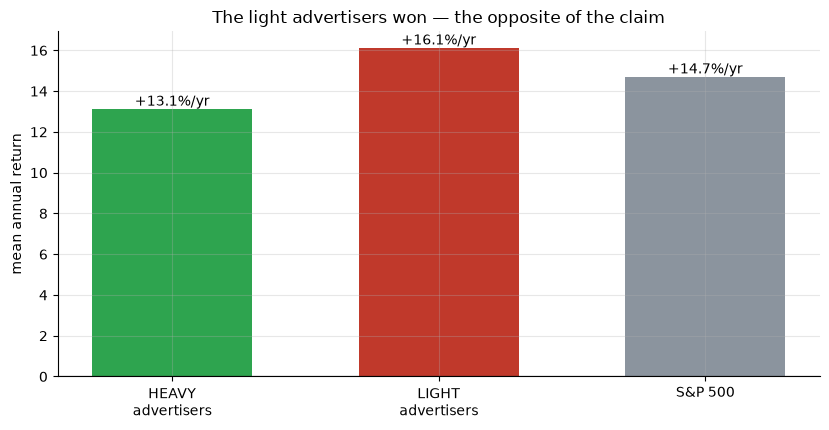

heavy +13.1%/yr | light +16.1%/yr | SPY +14.7%/yr


In [3]:
if HAVE_REAL:
    r = st.race(REAL, SIG, frac=1/3, cost_bps=R['cost_bps'], borrow_bps=R['borrow_bps'], n_shuffles=200)
    ln, sh_ = st.summarize(r['long'])['mean_ann']*100, st.summarize(r['short'])['mean_ann']*100
    spy = st.summarize(r['spy'])['mean_ann']*100
else:
    ln, sh_, spy = R['long_mean'], R['short_mean'], R['spy_mean']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['HEAVY\nadvertisers','LIGHT\nadvertisers','S&P 500'], [ln, sh_, spy],
       color=[GREEN, RED, GREY], width=.6)
for i,v in enumerate([ln, sh_, spy]): ax.annotate(f'{v:+.1f}%/yr',(i,v),ha='center',va='bottom')
ax.set_ylabel('mean annual return'); ax.axhline(0,c='k',lw=.8)
ax.set_title('The light advertisers won — the opposite of the claim')
plt.tight_layout(); plt.show()
print(f'heavy {ln:+.1f}%/yr | light {sh_:+.1f}%/yr | SPY {spy:+.1f}%/yr')

There it is. The **light** advertisers returned about **+16%/yr**, the **heavy** advertisers about **+13%/yr** — so the brand-capital long-short (heavy minus light) *lost* roughly **3.0%/yr**, the wrong sign for the claim. But before reading anything into that, the crucial question: **is the gap even real, or just noise?**

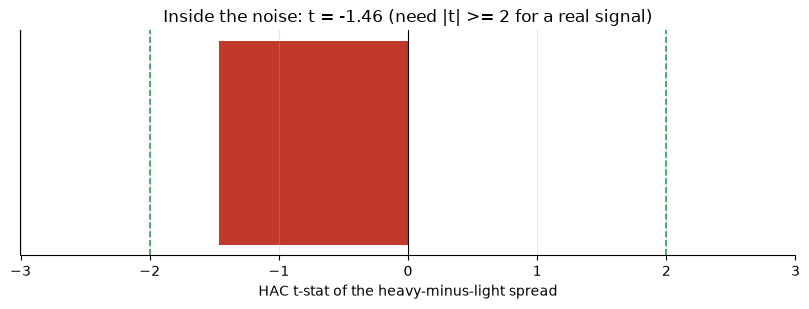

spread -3.00%/yr at HAC t = -1.46 -> indistinguishable from zero


In [4]:
if HAVE_REAL:
    t = r['test_ls']['tstat']; m = r['test_ls']['mean_ann']*100
else:
    t = R['ls_t']; m = R['ls_mean']
fig, ax = plt.subplots(figsize=(8.2, 3.2))
ax.barh([0], [t], color=(RED if abs(t)<2 else GREEN), height=.5)
ax.axvline(2, ls='--', c=GREEN, lw=1.2); ax.axvline(-2, ls='--', c=GREEN, lw=1.2)
ax.axvline(0, c='k', lw=.8)
ax.set_yticks([]); ax.set_xlim(-3, 3)
ax.set_xlabel('HAC t-stat of the heavy-minus-light spread')
ax.set_title(f'Inside the noise: t = {t:+.2f} (need |t| >= 2 for a real signal)')
ax.annotate('|t|=2 bar', (2, .35), color=GREEN, ha='center')
plt.tight_layout(); plt.show()
print(f'spread {m:+.2f}%/yr at HAC t = {t:+.2f} -> indistinguishable from zero')

The spread's *t*-stat is **-1.46** — nowhere near the ±2 bar. So the honest statement isn't "heavy advertisers lose" — it's **there is no advertising premium here, in either direction.** The negative point estimate is just this decade's sector weather (unglamorous retailers beat defensive staples) blowing through a signal that carries no independent information.

## 5 · The verdict

- **Signal — None.** The claimed premium is a *positive* one; we find a **negative** point estimate (-3.0%/yr) that is statistically indistinguishable from zero (*t* = -1.46). No brand premium on this tape.
- **Tradability — Mirage.** You can't trade a wrong-signed, insignificant spread — and a long-short pays short-borrow on top, making the net even worse.

The idea isn't stupid — it's a real research thesis. It just doesn't survive contact with a clean, point-in-time tape of the firms that actually disclose their ad spend.

## 6 · Going further 🚪

- **Why might the premium be missing here when papers find it?** Two honest reasons: (1) *coverage* — since 2015 most firms stopped disclosing advertising, so any tradable basket is a thin, self-selected slice; (2) *style* — over 2010-2026 the heavy advertisers are mostly defensive staples, which simply had a poor decade versus everything else, swamping any faint intangible effect.
- **The better denominator?** The R&D literature finds the mispricing lives when you scale by *market value*, not sales — see [study 525](../../525-r-and-d-intensity/). An advertising/market-cap version is the natural next test.
- **Sibling studies (the dedup):** [525-r-and-d-intensity](../../525-r-and-d-intensity/), [526-intangible-value](../../526-intangible-value/), [400-patent-intensity](../../400-patent-intensity/) — same intangible-mispricing family, different intangibles. See [docs/references.md](docs/references.md).

*Think advertising intensity pays once you scale it right, or clean up the survivorship? Show a net, certifiable spread on a defensible universe — then we'll talk.*